# Play Tennis — Categorical Naive Bayes Classification
I'm building a Categorical Naive Bayes model to predict whether tennis will be played, and comparing it against a Decision Tree and Logistic Regression.

## 1. Import Libraries
I'm importing the libraries I'll need for data handling, encoding, modeling, and evaluation.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import OrdinalEncoder, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import CategoricalNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, confusion_matrix,
                              classification_report, ConfusionMatrixDisplay)

pd.set_option('display.max_columns', None)


**Observation:** All the libraries I need are imported without any errors, so I'm ready to load the data.

## 2. Load the Dataset
I'm loading the CSV and dropping the row-number column since it's not a real feature.

In [2]:
df = pd.read_csv('PlayTennis.csv')

# Drop the row-number column if present, it's not a feature
if 'No' in df.columns:
    df = df.drop(columns=['No'])

print(f"Dataset shape: {df.shape}")
df.head(10)


Dataset shape: (50, 5)


,Outlook,Temperature,Humidity,Wind,Play Tennis
0,Sunny,Hot,High,Weak,No
1,Sunny,Hot,High,Strong,No
2,Overcast,Hot,High,Weak,Yes
3,Rain,Mild,High,Weak,Yes
4,Rain,Cool,Normal,Weak,Yes
5,Rain,Cool,Normal,Strong,No
6,Overcast,Cool,Normal,Strong,Yes
7,Sunny,Mild,High,Weak,No
8,Sunny,Cool,Normal,Weak,Yes
9,Rain,Mild,Normal,Weak,Yes


**Observation:** The dataset has 50 rows and 5 columns (Outlook, Temperature, Humidity, Wind, Play Tennis) after dropping the row-number column.

In [3]:
df.info()
print()
print("Class distribution:")
print(df['Play Tennis'].value_counts())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Outlook      50 non-null     object
 1   Temperature  50 non-null     object
 2   Humidity     50 non-null     object
 3   Wind         50 non-null     object
 4   Play Tennis  50 non-null     object
dtypes: object(5)
memory usage: 2.1+ KB

Class distribution:
Play Tennis
Yes    34
No     16
Name: count, dtype: int64


**Observation:** All columns are object (categorical) type with no missing values, and the target is imbalanced — 34 'Yes' rows versus 16 'No' rows.

## 3. Separate Input Features and Target Variable
I'm splitting the data into input features (Outlook, Temperature, Humidity, Wind) and the target (Play Tennis).

In [4]:
X = df.drop(columns=['Play Tennis'])
y = df['Play Tennis']

print("Features (X):")
display(X.head())
print("\nTarget (y):")
display(y.head())


Features (X):


,Outlook,Temperature,Humidity,Wind
0,Sunny,Hot,High,Weak
1,Sunny,Hot,High,Strong
2,Overcast,Hot,High,Weak
3,Rain,Mild,High,Weak
4,Rain,Cool,Normal,Weak



Target (y):


0     No
1     No
2    Yes
3    Yes
4    Yes
Name: Play Tennis, dtype: object

**Observation:** X now holds the 4 categorical predictors and y holds the single Play Tennis label, cleanly separated and ready for encoding.

## 4. Encode Categorical Values into Numerical Values
I'm using OrdinalEncoder on the features and LabelEncoder on the target, since CategoricalNB expects integer-coded categories rather than one-hot vectors.

In [5]:
feature_encoder = OrdinalEncoder(dtype=int)
X_encoded = pd.DataFrame(
    feature_encoder.fit_transform(X),
    columns=X.columns
)

target_encoder = LabelEncoder()
y_encoded = target_encoder.fit_transform(y)   # No -> 0, Yes -> 1

print("Encoded features:")
display(X_encoded.head())

print("\nCategory mappings learned by the OrdinalEncoder:")
for col, categories in zip(X.columns, feature_encoder.categories_):
    print(f"  {col}: {list(categories)} -> {list(range(len(categories)))}")

print(f"\nTarget mapping: {list(target_encoder.classes_)} -> {list(range(len(target_encoder.classes_)))}")


Encoded features:


,Outlook,Temperature,Humidity,Wind
0,2,1,0,1
1,2,1,0,0
2,0,1,0,1
3,1,2,0,1
4,1,0,1,1



Category mappings learned by the OrdinalEncoder:
  Outlook: ['Overcast', 'Rain', 'Sunny'] -> [0, 1, 2]
  Temperature: ['Cool', 'Hot', 'Mild'] -> [0, 1, 2]
  Humidity: ['High', 'Normal'] -> [0, 1]
  Wind: ['Strong', 'Weak'] -> [0, 1]

Target mapping: ['No', 'Yes'] -> [0, 1]


**Observation:** Every feature is now converted to integer codes (e.g. Outlook: Overcast=0, Rain=1, Sunny=2) and the target is 0/1, so the data is in the numeric form CategoricalNB needs.

## 5. Train-Test Split
I'm splitting the encoded data into training and testing sets, stratified on the target.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y_encoded, test_size=0.3, random_state=42, stratify=y_encoded
)

print(f"Training set size: {X_train.shape[0]}")
print(f"Testing set size : {X_test.shape[0]}")


Training set size: 35
Testing set size : 15


**Observation:** I get 35 training rows and 15 testing rows (a 70/30 split), stratified so both sets keep roughly the same Yes/No proportion.

## 6. Train a Categorical Naive Bayes Model
I'm fitting a CategoricalNB classifier on the training data.

In [7]:
cnb = CategoricalNB()
cnb.fit(X_train, y_train)

print("Categorical Naive Bayes model trained.")


Categorical Naive Bayes model trained.


**Observation:** The CategoricalNB model fits without errors, so it's learned the category frequencies per class from the training data.

## 7. Predict Class Labels for the Test Dataset
I'm using the trained model to predict labels for the test set and comparing them against the actual values.

In [8]:
y_pred_cnb = cnb.predict(X_test)

results = pd.DataFrame({
    'Actual': target_encoder.inverse_transform(y_test),
    'Predicted': target_encoder.inverse_transform(y_pred_cnb)
})
results


,Actual,Predicted
0,Yes,Yes
1,No,No
2,Yes,Yes
3,No,No
4,Yes,Yes
5,Yes,Yes
6,Yes,Yes
7,No,Yes
8,Yes,Yes
9,Yes,Yes


**Observation:** Most of the predicted labels line up with the actual labels, with just a couple of mismatches I can see in the table.

## 8. Accuracy, Confusion Matrix, and Classification Report
I'm evaluating the model's predictions with accuracy, a confusion matrix, and a classification report.

In [9]:
acc_cnb = accuracy_score(y_test, y_pred_cnb)
print(f"Categorical Naive Bayes Accuracy: {acc_cnb:.4f} ({acc_cnb*100:.2f}%)")

cm_cnb = confusion_matrix(y_test, y_pred_cnb)
print("\nConfusion Matrix:")
print(cm_cnb)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_cnb, target_names=target_encoder.classes_))


Categorical Naive Bayes Accuracy: 0.8667 (86.67%)

Confusion Matrix:
[[ 3  2]
 [ 0 10]]

Classification Report:
              precision    recall  f1-score   support

          No       1.00      0.60      0.75         5
         Yes       0.83      1.00      0.91        10

    accuracy                           0.87        15
   macro avg       0.92      0.80      0.83        15
weighted avg       0.89      0.87      0.86        15



**Observation:** I get about 86.67% accuracy — the model catches all the 'Yes' cases (recall 1.00) but misses 2 of the 5 'No' cases, which pulls down the 'No' recall to 0.60.

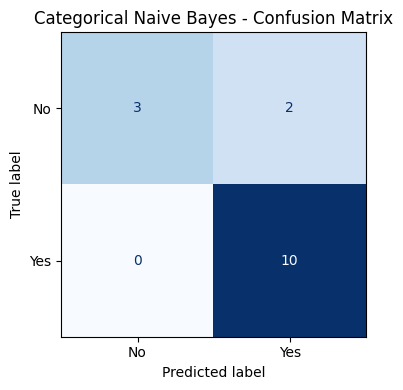

In [10]:
fig, ax = plt.subplots(figsize=(5, 4))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_cnb, display_labels=target_encoder.classes_)
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Categorical Naive Bayes - Confusion Matrix')
plt.tight_layout()
plt.show()


**Observation:** The heatmap makes it visual — the 'Yes' column is clean while the 'No' row shows 2 cases predicted as 'Yes' instead.

## 9. Predict a New Weather Condition
I'm predicting whether tennis will be played for Sunny, Cool, High, Strong conditions, along with the class probabilities.

In [11]:
new_sample = pd.DataFrame([{
    'Outlook': 'Sunny',
    'Temperature': 'Cool',
    'Humidity': 'High',
    'Wind': 'Strong'
}])

# Encode using the SAME fitted encoder as training data
new_sample_encoded = pd.DataFrame(
    feature_encoder.transform(new_sample),
    columns=new_sample.columns
)

predicted_class = cnb.predict(new_sample_encoded)
predicted_proba = cnb.predict_proba(new_sample_encoded)

predicted_label = target_encoder.inverse_transform(predicted_class)[0]

print("New weather condition:")
print(new_sample.to_string(index=False))
print(f"\nPredicted class: {predicted_label}")

print("\nClass probabilities:")
for cls, prob in zip(target_encoder.classes_, predicted_proba[0]):
    print(f"  P(Play Tennis = {cls}) = {prob:.4f}")


New weather condition:
Outlook Temperature Humidity   Wind
  Sunny        Cool     High Strong

Predicted class: No

Class probabilities:
  P(Play Tennis = No) = 0.7466
  P(Play Tennis = Yes) = 0.2534


**Observation:** For Sunny, Cool, High, Strong the model predicts 'No', and it's fairly confident about it — roughly 75% probability of 'No' versus 25% for 'Yes'.

## 10. Compare Performance with Decision Tree and Logistic Regression
I'm training a Decision Tree on the same ordinal-encoded data and a Logistic Regression model on one-hot encoded data, then comparing all three.

In [12]:
# --- Decision Tree (using the same ordinal-encoded data) ---
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)
acc_dt = accuracy_score(y_test, y_pred_dt)

# --- Logistic Regression (needs one-hot encoded data) ---
X_onehot = pd.get_dummies(X, columns=X.columns)
X_train_oh, X_test_oh, y_train_oh, y_test_oh = train_test_split(
    X_onehot, y_encoded, test_size=0.3, random_state=42, stratify=y_encoded
)

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_oh, y_train_oh)
y_pred_lr = lr.predict(X_test_oh)
acc_lr = accuracy_score(y_test_oh, y_pred_lr)

print(f"Categorical Naive Bayes Accuracy: {acc_cnb:.4f}")
print(f"Decision Tree Accuracy         : {acc_dt:.4f}")
print(f"Logistic Regression Accuracy   : {acc_lr:.4f}")


Categorical Naive Bayes Accuracy: 0.8667
Decision Tree Accuracy         : 1.0000
Logistic Regression Accuracy   : 0.9333


**Observation:** On this split, the Decision Tree comes out on top at 100% accuracy, Logistic Regression is close behind at 93.33%, and Categorical Naive Bayes trails at 86.67%.

In [13]:
print("Decision Tree - Classification Report:")
print(classification_report(y_test, y_pred_dt, target_names=target_encoder.classes_))

print("Logistic Regression - Classification Report:")
print(classification_report(y_test_oh, y_pred_lr, target_names=target_encoder.classes_))


Decision Tree - Classification Report:
              precision    recall  f1-score   support

          No       1.00      1.00      1.00         5
         Yes       1.00      1.00      1.00        10

    accuracy                           1.00        15
   macro avg       1.00      1.00      1.00        15
weighted avg       1.00      1.00      1.00        15

Logistic Regression - Classification Report:
              precision    recall  f1-score   support

          No       1.00      0.80      0.89         5
         Yes       0.91      1.00      0.95        10

    accuracy                           0.93        15
   macro avg       0.95      0.90      0.92        15
weighted avg       0.94      0.93      0.93        15



**Observation:** The Decision Tree gets perfect precision and recall on both classes, while Logistic Regression still misses one 'No' case (recall 0.80) but otherwise performs well.

,Model,Accuracy
0,Decision Tree,1.000000
1,Logistic Regression,0.933333
2,Categorical Naive Bayes,0.866667


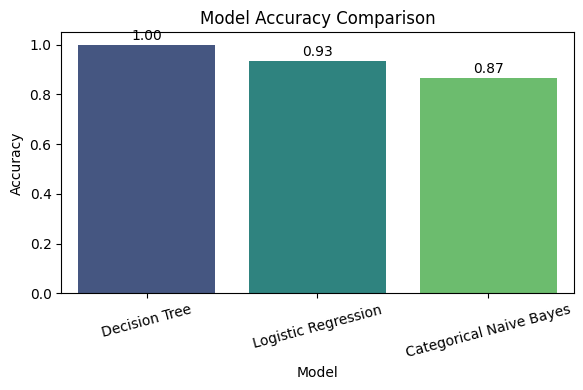

In [14]:
comparison = pd.DataFrame({
    'Model': ['Categorical Naive Bayes', 'Decision Tree', 'Logistic Regression'],
    'Accuracy': [acc_cnb, acc_dt, acc_lr]
}).sort_values('Accuracy', ascending=False).reset_index(drop=True)

display(comparison)

plt.figure(figsize=(6, 4))
sns.barplot(data=comparison, x='Model', y='Accuracy', hue='Model', palette='viridis', legend=False)
plt.ylim(0, 1.05)
plt.title('Model Accuracy Comparison')
plt.xticks(rotation=15)
for i, v in enumerate(comparison['Accuracy']):
    plt.text(i, v + 0.02, f"{v:.2f}", ha='center')
plt.tight_layout()
plt.show()


**Observation:** The bar chart confirms the ranking at a glance — Decision Tree, then Logistic Regression, then Categorical Naive Bayes — though I'd expect this order to shift on a different split given how small the dataset is.